In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sample = pd.read_csv("../data/raw/biospecimen/sample.tsv", sep="\t")

clinical = pd.read_csv("../data/raw/clinical/clinical.tsv", sep="\t")
exposure = pd.read_csv("../data/raw/clinical/exposure.tsv", sep="\t")
follow_up = pd.read_csv("../data/raw/clinical/follow_up.tsv", sep="\t")
pathology = pd.read_csv("../data/raw/clinical/pathology_detail.tsv", sep="\t")

indian_liver_patient = pd.read_csv("../data/raw/indian_liver_patient.csv")
liver_disease = pd.read_csv("../data/raw/Liver_Disease_Patient.csv", encoding='latin-1')

### Sample Dataset

In [4]:
print(f"Shape: {sample.shape}")
print("Columns:", sample.columns.tolist())
sample.head(3)

Shape: (1168, 34)
Columns: ['project.project_id', 'cases.case_id', 'cases.submitter_id', 'samples.biospecimen_anatomic_site', 'samples.biospecimen_laterality', 'samples.catalog_reference', 'samples.current_weight', 'samples.days_to_collection', 'samples.days_to_sample_procurement', 'samples.diagnosis_pathologically_confirmed', 'samples.distance_normal_to_tumor', 'samples.distributor_reference', 'samples.freezing_method', 'samples.growth_rate', 'samples.initial_weight', 'samples.intermediate_dimension', 'samples.longest_dimension', 'samples.method_of_sample_procurement', 'samples.passage_count', 'samples.pathology_report_uuid', 'samples.preservation_method', 'samples.sample_id', 'samples.sample_ordinal', 'samples.sample_type', 'samples.shortest_dimension', 'samples.specimen_type', 'samples.state', 'samples.submitter_id', 'samples.time_between_clamping_and_freezing', 'samples.time_between_excision_and_freezing', 'samples.tissue_collection_type', 'samples.tissue_type', 'samples.tumor_code

,project.project_id,cases.case_id,cases.submitter_id,samples.biospecimen_anatomic_site,samples.biospecimen_laterality,samples.catalog_reference,samples.current_weight,samples.days_to_collection,samples.days_to_sample_procurement,samples.diagnosis_pathologically_confirmed,...,samples.shortest_dimension,samples.specimen_type,samples.state,samples.submitter_id,samples.time_between_clamping_and_freezing,samples.time_between_excision_and_freezing,samples.tissue_collection_type,samples.tissue_type,samples.tumor_code_id,samples.tumor_descriptor
0,TCGA-LIHC,834cff01-3c12-42fa-abbe-ae0ae168c568,TCGA-DD-AAVR,'--,'--,'--,'--,2355,'--,'--,...,'--,Peripheral Blood NOS,released,TCGA-DD-AAVR-10A,'--,'--,'--,Normal,'--,Not Applicable
1,TCGA-LIHC,834cff01-3c12-42fa-abbe-ae0ae168c568,TCGA-DD-AAVR,'--,'--,'--,'--,'--,0,'--,...,'--,Solid Tissue,released,TCGA-DD-AAVR-01Z,'--,'--,'--,Tumor,'--,Primary
2,TCGA-LIHC,834cff01-3c12-42fa-abbe-ae0ae168c568,TCGA-DD-AAVR,'--,'--,'--,'--,2355,'--,'--,...,'--,Unknown,released,TCGA-DD-AAVR-01A,'--,'--,'--,Tumor,'--,Primary


In [5]:
type_cols=[ c for c in sample.columns if "type" in c.lower() or "sample" in c.lower()]
if type_cols:
    col = type_cols[0]
    print (sample[col].value_counts())

samples.biospecimen_anatomic_site
'--    1168
Name: count, dtype: int64


### Clinical Dataset

In [6]:
print(f"Shape: {clinical.shape}")
print("Columns:", clinical.columns.tolist())
clinical.head(3)

Shape: (2977, 201)
Columns: ['project.project_id', 'cases.case_id', 'cases.consent_type', 'cases.days_to_consent', 'cases.days_to_lost_to_followup', 'cases.disease_type', 'cases.index_date', 'cases.lost_to_followup', 'cases.primary_site', 'cases.submitter_id', 'demographic.age_at_index', 'demographic.age_is_obfuscated', 'demographic.cause_of_death', 'demographic.cause_of_death_source', 'demographic.country_of_birth', 'demographic.country_of_residence_at_enrollment', 'demographic.days_to_birth', 'demographic.days_to_death', 'demographic.demographic_id', 'demographic.education_level', 'demographic.ethnicity', 'demographic.gender', 'demographic.marital_status', 'demographic.occupation_duration_years', 'demographic.population_group', 'demographic.race', 'demographic.sex_at_birth', 'demographic.submitter_id', 'demographic.vital_status', 'demographic.year_of_birth', 'demographic.year_of_death', 'diagnoses.adrenal_hormone', 'diagnoses.age_at_diagnosis', 'diagnoses.ajcc_clinical_m', 'diagnoses

,project.project_id,cases.case_id,cases.consent_type,cases.days_to_consent,cases.days_to_lost_to_followup,cases.disease_type,cases.index_date,cases.lost_to_followup,cases.primary_site,cases.submitter_id,...,treatments.treatment_duration,treatments.treatment_effect,treatments.treatment_effect_indicator,treatments.treatment_frequency,treatments.treatment_id,treatments.treatment_intent_type,treatments.treatment_or_therapy,treatments.treatment_outcome,treatments.treatment_outcome_duration,treatments.treatment_type
0,TCGA-LIHC,0004d251-3f70-4395-b175-c94c2f5b1b81,Informed Consent,1305,'--,Adenomas and Adenocarcinomas,Diagnosis,No,Liver and intrahepatic bile ducts,TCGA-DD-AAVP,...,'--,'--,'--,'--,0f4d48c5-6a29-4671-a5cc-e73dc3efdaa6,Adjuvant,no,'--,'--,"Radiation Therapy, NOS"
1,TCGA-LIHC,0004d251-3f70-4395-b175-c94c2f5b1b81,Informed Consent,1305,'--,Adenomas and Adenocarcinomas,Diagnosis,No,Liver and intrahepatic bile ducts,TCGA-DD-AAVP,...,'--,'--,'--,'--,28d698d5-b9d7-5897-b2ff-c1e36cd4bcf7,Adjuvant,no,'--,'--,"Pharmaceutical Therapy, NOS"
2,TCGA-LIHC,0004d251-3f70-4395-b175-c94c2f5b1b81,Informed Consent,1305,'--,Adenomas and Adenocarcinomas,Diagnosis,No,Liver and intrahepatic bile ducts,TCGA-DD-AAVP,...,'--,'--,'--,'--,4f64e267-b8c8-4119-8be7-90459321e5a1,Adjuvant,yes,'--,'--,"Ablation or Embolization, NOS"


In [7]:
missing = clinical.isnull().sum()
missing_pct =(missing / len(clinical)* 100) .round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing Percentage": missing_pct})
print(missing_df)

                                       Missing Count  Missing Percentage
project.project_id                                 0                 0.0
cases.case_id                                      0                 0.0
cases.consent_type                                 0                 0.0
cases.days_to_consent                              0                 0.0
cases.days_to_lost_to_followup                     0                 0.0
...                                              ...                 ...
treatments.treatment_intent_type                   0                 0.0
treatments.treatment_or_therapy                    0                 0.0
treatments.treatment_outcome                       0                 0.0
treatments.treatment_outcome_duration              0                 0.0
treatments.treatment_type                          0                 0.0

[201 rows x 2 columns]


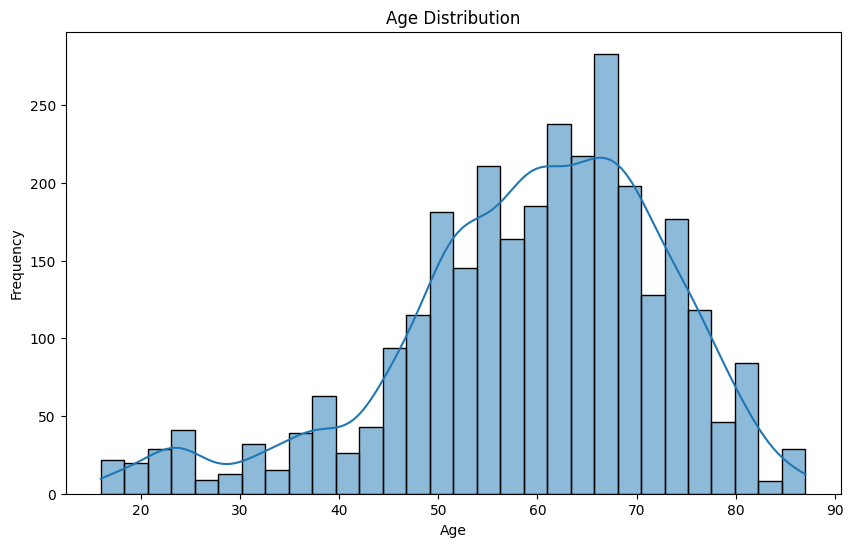

count    2973.000000
mean       59.257989
std        13.733612
min        16.000000
25%        52.000000
50%        61.000000
75%        69.000000
max        87.000000
Name: demographic.age_at_index, dtype: float64


In [8]:
age_cols = [c for c in clinical.columns if "age" in c.lower()]
if age_cols:
    age_col = age_cols[0]
    clinical[age_col] = pd.to_numeric(clinical[age_col], errors="coerce")
    plt.figure(figsize=(10, 6))
    sns.histplot(clinical[age_col].dropna(), bins=30, kde=True)
    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Frequency")
    plt.show()
    print(clinical[age_cols[0]].describe())

### Follow_Up Dataset : Target

In [9]:
print(f"Shape: {follow_up.shape}")
print("Columns:", follow_up.columns.tolist())
follow_up.head(3)

Shape: (4811, 152)
Columns: ['project.project_id', 'cases.case_id', 'cases.submitter_id', 'follow_ups.adverse_event', 'follow_ups.adverse_event_grade', 'follow_ups.barretts_esophagus_goblet_cells_present', 'follow_ups.cause_of_response', 'follow_ups.days_to_adverse_event', 'follow_ups.days_to_first_event', 'follow_ups.days_to_follow_up', 'follow_ups.days_to_imaging', 'follow_ups.days_to_progression', 'follow_ups.days_to_progression_free', 'follow_ups.days_to_recurrence', 'follow_ups.discontiguous_lesion_count', 'follow_ups.disease_response', 'follow_ups.ecog_performance_status', 'follow_ups.evidence_of_progression_type', 'follow_ups.evidence_of_recurrence_type', 'follow_ups.first_event', 'follow_ups.follow_up_id', 'follow_ups.histologic_progression', 'follow_ups.history_of_tumor', 'follow_ups.history_of_tumor_type', 'follow_ups.hormone_replacement_therapy_type', 'follow_ups.imaging_anatomic_site', 'follow_ups.imaging_findings', 'follow_ups.imaging_result', 'follow_ups.imaging_suv', 'fo

,project.project_id,cases.case_id,cases.submitter_id,follow_ups.adverse_event,follow_ups.adverse_event_grade,follow_ups.barretts_esophagus_goblet_cells_present,follow_ups.cause_of_response,follow_ups.days_to_adverse_event,follow_ups.days_to_first_event,follow_ups.days_to_follow_up,...,other_clinical_attributes.undescended_testis_corrected,other_clinical_attributes.undescended_testis_corrected_age,other_clinical_attributes.undescended_testis_corrected_age_range,other_clinical_attributes.undescended_testis_corrected_laterality,other_clinical_attributes.undescended_testis_corrected_method,other_clinical_attributes.undescended_testis_history,other_clinical_attributes.undescended_testis_history_laterality,other_clinical_attributes.viral_hepatitis_serology_tests,other_clinical_attributes.weeks_gestation_at_birth,other_clinical_attributes.weight
0,TCGA-LIHC,0004d251-3f70-4395-b175-c94c2f5b1b81,TCGA-DD-AAVP,'--,'--,'--,'--,'--,'--,903,...,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--
1,TCGA-LIHC,0004d251-3f70-4395-b175-c94c2f5b1b81,TCGA-DD-AAVP,'--,'--,'--,'--,'--,'--,903,...,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--
2,TCGA-LIHC,0004d251-3f70-4395-b175-c94c2f5b1b81,TCGA-DD-AAVP,'--,'--,'--,'--,'--,'--,'--,...,'--,'--,'--,'--,'--,'--,'--,'--,'--,'--


In [10]:
vital_status_col = [c for c in follow_up.columns if "vital" in c.lower() ]
if vital_status_col:
    col = vital_status_col[0]
    print (follow_up[col].value_counts())


### Pathology Dataset : Stage & Serverity

In [11]:
print(f"Shape: {pathology.shape}")
print("Columns:", pathology.columns.tolist())
pathology.head(3)

Shape: (377, 87)
Columns: ['project.project_id', 'cases.case_id', 'cases.submitter_id', 'diagnoses.diagnosis_id', 'diagnoses.submitter_id', 'pathology_details.additional_pathology_findings', 'pathology_details.anaplasia_present', 'pathology_details.anaplasia_present_type', 'pathology_details.bone_marrow_malignant_cells', 'pathology_details.breslow_thickness', 'pathology_details.breslow_thickness_category', 'pathology_details.circumferential_resection_margin', 'pathology_details.columnar_mucosa_present', 'pathology_details.consistent_pathology_review', 'pathology_details.days_to_pathology_detail', 'pathology_details.dysplasia_degree', 'pathology_details.dysplasia_type', 'pathology_details.epithelioid_cell_percent', 'pathology_details.epithelioid_cell_percent_range', 'pathology_details.extracapsular_extension', 'pathology_details.extracapsular_extension_present', 'pathology_details.extranodal_extension', 'pathology_details.extraocular_nodule_size', 'pathology_details.extrascleral_extensi

,project.project_id,cases.case_id,cases.submitter_id,diagnoses.diagnosis_id,diagnoses.submitter_id,pathology_details.additional_pathology_findings,pathology_details.anaplasia_present,pathology_details.anaplasia_present_type,pathology_details.bone_marrow_malignant_cells,pathology_details.breslow_thickness,...,pathology_details.tumor_infiltrating_macrophages,pathology_details.tumor_largest_dimension_diameter,pathology_details.tumor_length_measurement,pathology_details.tumor_level_prostate,pathology_details.tumor_shape,pathology_details.tumor_thickness,pathology_details.tumor_width_measurement,pathology_details.vascular_invasion_present,pathology_details.vascular_invasion_type,pathology_details.zone_of_origin_prostate
0,TCGA-LIHC,0004d251-3f70-4395-b175-c94c2f5b1b81,TCGA-DD-AAVP,042507ff-0397-5464-891f-aa527c20f2eb,TCGA-DD-AAVP_diagnosis,Inflammation,'--,'--,'--,'--,...,'--,'--,'--,'--,'--,'--,'--,No,No Vascular Invasion,'--
1,TCGA-LIHC,001887aa-36d0-463f-8bca-dec7043b4f2e,TCGA-DD-A4NP,4e399cb2-5fd8-5e6a-8236-e26c7e4e9440,TCGA-DD-A4NP_diagnosis,'--,'--,'--,'--,'--,...,'--,'--,'--,'--,'--,'--,'--,No,No Vascular Invasion,'--
2,TCGA-LIHC,00f209c3-041a-4c6e-8b0f-6383eb3c85fc,TCGA-BC-4073,ab52cd53-015f-52a3-a8cc-2d164f0b2be5,TCGA-BC-4073_diagnosis,'--,'--,'--,'--,'--,...,'--,'--,'--,'--,'--,'--,'--,Yes,Macro,'--


In [12]:
stage_cols = [c for c in pathology.columns if "stage" in c.lower() or "grade" in c.lower()]
if stage_cols:
    col = stage_cols[0]
    print (pathology[col].value_counts())   

### Indian Liver Patient

In [13]:
indian_liver_patient["Dataset"]= indian_liver_patient["Dataset"].map({1:1, 2:0})
print(f"Shape: {indian_liver_patient.shape}")
indian_liver_patient.isnull().sum()

disease_count= (indian_liver_patient["Dataset"] ==1).sum()
disease = disease_count / len(indian_liver_patient) * 100
print(f"Disease : {disease:.2f}%")

healthy_count= (indian_liver_patient["Dataset"] ==0).sum()
healthy = healthy_count / len(indian_liver_patient) * 100
print(f"Healthy : {healthy:.2f}%")

print("Statistics: ")
print(indian_liver_patient.describe().round(2))



Shape: (583, 11)
Disease : 71.36%
Healthy : 28.64%
Statistics: 


          Age  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
count  583.00           583.00            583.00                583.00   
mean    44.75             3.30              1.49                290.58   
std     16.19             6.21              2.81                242.94   
min      4.00             0.40              0.10                 63.00   
25%     33.00             0.80              0.20                175.50   
50%     45.00             1.00              0.30                208.00   
75%     58.00             2.60              1.30                298.00   
max     90.00            75.00             19.70               2110.00   

       Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Protiens  \
count                    583.00                      583.00          583.00   
mean                      80.71                      109.91            6.48   
std                      182.62                      288.92            1.09   
min              

### Liver Disease Dataset

In [14]:
print(f"Shape: {liver_disease.shape}")
print("Columns:", liver_disease.columns.tolist())
liver_disease.head(3)


Shape: (30691, 11)
Columns: ['Age of the patient', 'Gender of the patient', 'Total Bilirubin', 'Direct Bilirubin', '\xa0Alkphos Alkaline Phosphotase', '\xa0Sgpt Alamine Aminotransferase', 'Sgot Aspartate Aminotransferase', 'Total Protiens', '\xa0ALB Albumin', 'A/G Ratio Albumin and Globulin Ratio', 'Result']


,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1


In [15]:
missing_liver = liver_disease.isnull().sum()
missing_liver_pct =(missing_liver / len(liver_disease)* 100) .round(2)
missing_liver_df = pd.DataFrame({"Missing Count": missing_liver, "Missing Percentage": missing_liver_pct})
print(missing_liver_df)

                                      Missing Count  Missing Percentage
Age of the patient                                2                0.01
Gender of the patient                           902                2.94
Total Bilirubin                                 648                2.11
Direct Bilirubin                                561                1.83
 Alkphos Alkaline Phosphotase                   796                2.59
 Sgpt Alamine Aminotransferase                  538                1.75
Sgot Aspartate Aminotransferase                 462                1.51
Total Protiens                                  463                1.51
 ALB Albumin                                    494                1.61
A/G Ratio Albumin and Globulin Ratio            559                1.82
Result                                            0                0.00
